In [161]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
df_processed = pd.read_pickle("dataframes/df_processed.pkl")

crime_codes = {
    'ICCS0101': 'Intentional homicide',
    'ICCS0301': 'Sexual violence',
    'ICCS03011': 'Rape',
    'ICCS0401': 'Robbery',
    'ICCS0502': 'Theft',
}

In [163]:
df_cluster = df_processed.groupby('country')[['asylum_per_100k', 'crime_per_100k']].mean()

In [164]:
# 2. K-Means: asylum applications per country (mean per 100k)

# Standardize the feature and run 1D K-Means on asylum_per_100k
scaler_asylum = StandardScaler()
X_asylum = scaler_asylum.fit_transform(df_cluster[['asylum_per_100k']])
kmeans_asylum = KMeans(n_clusters=3, random_state=42)
df_cluster['cluster_asylum'] = kmeans_asylum.fit_predict(X_asylum)

# Inspect a few rows
df_cluster[['asylum_per_100k', 'cluster_asylum']]

,asylum_per_100k,cluster_asylum
country,,
Austria,437.005959,0
Belgium,175.247343,1
Bulgaria,145.937788,1
Croatia,33.136121,1
Cyprus,824.036139,2
Czechia,10.525457,1
Denmark,115.919451,1
Estonia,30.455826,1
Finland,111.864138,1


In [165]:
# 3. K-Means: total crime per country (mean per 100k)

# Standardize the feature and run 1D K-Means on crime_per_100k
scaler_crime = StandardScaler()
X_crime = scaler_crime.fit_transform(df_cluster[['crime_per_100k']])
kmeans_crime = KMeans(n_clusters=3, random_state=42)
df_cluster['cluster_crime'] = kmeans_crime.fit_predict(X_crime)

# Optional: compare how many countries fall into each cluster
print('Asylum clusters value counts:')
print(df_cluster['cluster_asylum'].value_counts().sort_index())

print('\nCrime clusters value counts:')
print(df_cluster['cluster_crime'].value_counts().sort_index())

Asylum clusters value counts:
cluster_asylum
0     8
1    20
2     1
Name: count, dtype: int64

Crime clusters value counts:
cluster_crime
0    13
1    14
2     2
Name: count, dtype: int64


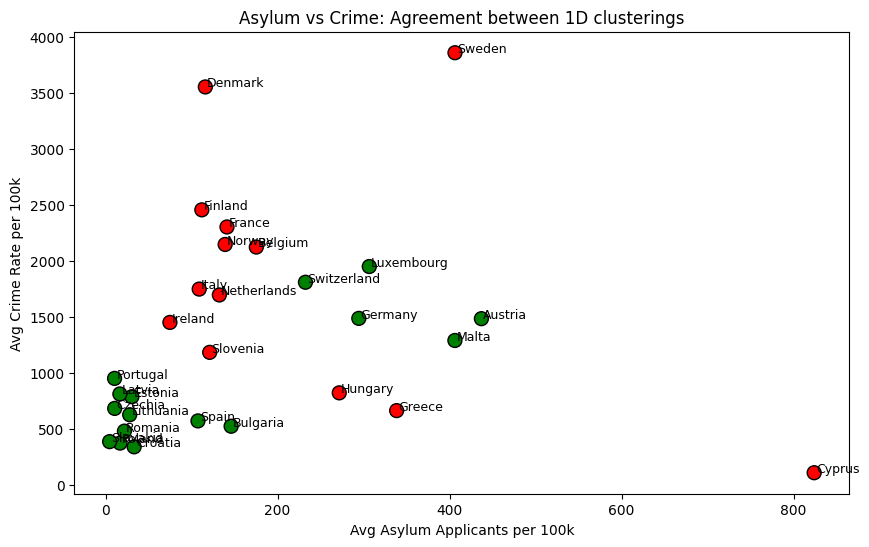

In [166]:
# 6. Plot asylum vs crime with color = cluster agreement

# Create a color flag: green if clusters agree, red if different
same_cluster = df_cluster['cluster_asylum'] == df_cluster['cluster_crime']
colors = same_cluster.map({True: 'green', False: 'red'})

plt.figure(figsize=(10, 6))
plt.scatter(
    df_cluster['asylum_per_100k'],
    df_cluster['crime_per_100k'],
    c=colors,
    s=100,
    edgecolor='k'
 )

# Label each point with country name
for country, row in df_cluster.iterrows():
    plt.text(row['asylum_per_100k'] + 2, row['crime_per_100k'] + 2, country, fontsize=9)

plt.title('Asylum vs Crime: Agreement between 1D clusterings')
plt.xlabel('Avg Asylum Applicants per 100k')
plt.ylabel('Avg Crime Rate per 100k')
plt.show()

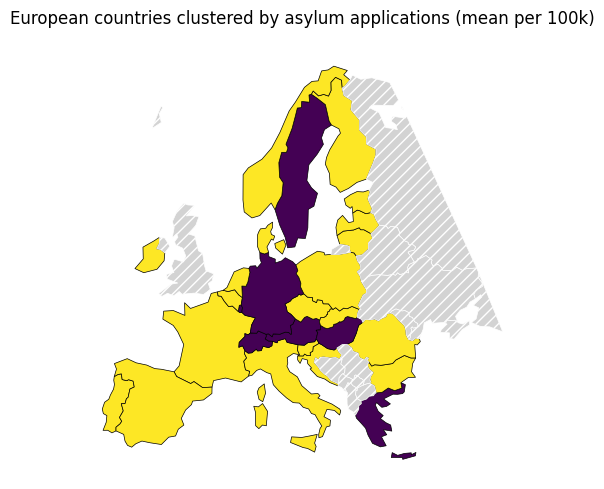

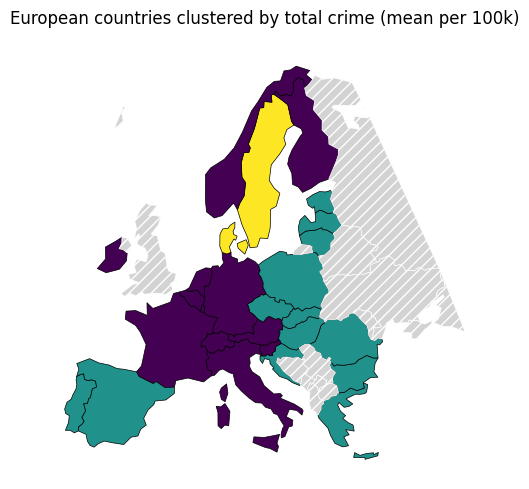

In [170]:
# 4. Plot maps of Europe for both clusterings (single vector source)

import geopandas as gpd
from shapely.geometry import box

# URL to Natural Earth admin-0 countries (110m resolution)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

# Load world country borders
world = gpd.read_file(url)

# Filter to Europe by continent
europe = world[world["CONTINENT"] == "Europe"].copy()

# Define Europe bounding box (lon/lat) and clip geometries
europe_bbox = box(-15, 30, 40, 72)
europe = gpd.clip(europe, europe_bbox)

# Merge your cluster data
df_cluster_reset = df_cluster.reset_index()
gdf = europe.merge(
    df_cluster_reset,
    left_on="NAME",   # Natural Earth uses "NAME" for country names
    right_on="country",
    how="left"
)

# Reproject to Web Mercator (optional, but consistent with other maps)
gdf_3857 = gdf.to_crs(epsg=3035)

# Map 1: clusters based on asylum applicants per 100k
fig, ax = plt.subplots(figsize=(7, 5))
gdf_3857.plot(
    column="cluster_asylum",
    ax=ax,
    cmap="viridis",
    edgecolor="black",
    linewidth=0.5,
    legend=False,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "hatch": "///",
        "label": "No data"
    }
)
ax.set_title("European countries clustered by asylum applications (mean per 100k)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Map 2: clusters based on crime rate per 100k
fig, ax = plt.subplots(figsize=(7, 5))
gdf_3857.plot(
    column="cluster_crime",
    ax=ax,
    cmap="viridis",
    edgecolor="black",
    linewidth=0.5,
    legend=False,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "hatch": "///",
        "label": "No data"
    }
)
ax.set_title("European countries clustered by total crime (mean per 100k)")
ax.set_axis_off()
plt.tight_layout()
plt.show()